In [3]:
import os
import pickle
import glob
import sys
import getpass
import importlib
from tqdm import tqdm
from pathlib import Path

# user path:
usrname = getpass.getuser()
# add paths:
sys.path.append(f'/Users/{usrname}/Desktop/Projects')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/bimanual_wrist')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/Functional_Fusion')
sys.path.append(f'/Users/{usrname}/Desktop/Projects/PcmPy')

import rsatoolbox as rsa
from rsatoolbox.io import spm as spm_io
import surfAnalysisPy as surf
import SUITPy as suit
import nibabel as nb
import nitools as nt
import PcmPy as pcm
import Functional_Fusion.atlas_map as am
import Functional_Fusion.reliability as rel

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import seaborn as sns

import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

import scipy
import scipy.io as sio
import numpy as np
import pandas as pd

import utils
importlib.reload(utils)

# SET PATHS:
baseDir = os.path.join('/Users', getpass.getuser(), 'Desktop', 'Projects', 'bimanual_wrist', 'data', 'fMRI')
bidsDir = 'BIDS'
anatomicalDir = 'anatomicals'
freesurferDir = 'surfaceFreesurfer'
surfacewbDir = 'surfaceWB' 
behavDir = 'behavioural'
regDir = 'ROI'
atlasDir = '/Volumes/diedrichsen_data$/data/Atlas_templates/fs_LR_32'
analysisDir = os.path.join(os.path.dirname(os.path.dirname(baseDir)), 'analysis')

tmpFigDir = os.path.join('/Users', getpass.getuser(), 'Dropbox (Personal)', 'bmw1_Manuscript', 'figures', 'plots')


## Bimanual

decompose the bimanual pattern into contra, ipsi, and interaction components

### run all regions

In [ ]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

labels = ['flx_flx',    'flx_flxup',   'flx_extup',   'flx_ext',   'flx_extdn',   'flx_flxdn',
          'flxup_flx',  'flxup_flxup', 'flxup_extup', 'flxup_ext', 'flxup_extdn', 'flxup_flxdn',
          'extup_flx',  'extup_flxup', 'extup_extup', 'extup_ext', 'extup_extdn', 'extup_flxdn',
          'ext_flx',    'ext_flxup',   'ext_extup',   'ext_ext',   'ext_extdn',   'ext_flxdn',
          'extdn_flx',  'extdn_flxup', 'extdn_extup', 'extdn_ext', 'extdn_extdn', 'extdn_flxdn',
          'flxdn_flx',  'flxdn_flxup', 'flxdn_extup', 'flxdn_ext', 'flxdn_extdn', 'flxdn_flxdn']
cmap = 'RdBu_r'
ncond = 36

G_model = {}
# Contra component:
cov = np.kron(np.eye(6), np.ones((6, 6)))
cov = pcm.centering(36) @ cov @ pcm.centering(36)
cov = cov/np.abs(np.trace(cov))/ncond
G_model['contra'] = cov

# Ipsilateral component:
cov = np.kron(np.ones((6, 6)), np.eye(6))
cov = pcm.centering(36) @ cov @ pcm.centering(36)
cov = cov/np.abs(np.trace(cov))/ncond
G_model['ipsi'] = cov  

# interaction term:
cov = np.eye(ncond)
cov = pcm.centering(36) @ cov @ pcm.centering(36)
cov = cov/np.abs(np.trace(cov))/ncond
G_model['interaction'] = cov

# OLS components:
# Generate the three model components, each one as a fixed model
A = np.zeros((ncond, 6))
for i in range(6):
    A[i*6:(i+1)*6, i] = 1.0
B = np.tile(np.eye(6), (6, 1))
I = np.eye(ncond)
# Orthogonalize the interaction effect
X = np.c_[A, B]
# Io = I - X @ np.linalg.pinv(X) @ I
Io = I # not orthogonalized interaction

# Now Build the second moment matrix and create the full model
# for data generation:
Gc = np.zeros((3, ncond, ncond))
Gc[0] = pcm.centering(ncond) @ A @ A.T @ pcm.centering(ncond) # contra
Gc[1] = pcm.centering(ncond) @ B @ B.T @ pcm.centering(ncond) # ipsi
Gc[2] = pcm.centering(ncond) @ Io @ Io.T @ pcm.centering(ncond) # interaction

var_df = {'region': [], 'hem': [], 'sn': [], 'component': [], 'variance': [], 'd2': [], 'd': []}
for region in regions:
    # load dataset:
    file_path_save = os.path.join(analysisDir, f'pcm_dataset_bimanual_{region}.npz')
    D = np.load(file_path_save, allow_pickle=True)
    hemisphere = D['hemisphere'].tolist()
    D = D['Y'].tolist()

    M = []
    M.append(pcm.ComponentModel('all', [Gc[0],Gc[1], Gc[2]]))

    # fit CKA individual:
    # print('Fitting CKA individual...')
    # T_CKA_ind, theta_CKA_ind, AIC = fit_CKA_individ(D, M, verbose=False, AIC=True)

    # ================================ fit PCM individual ================================
    print(f'{region} - Fitting PCM individual...')
    T_PCM_ind, theta_PCM_ind = pcm.fit_model_individ(D, M, fit_scale=False, verbose=False)

    # ================================ fit OLS individual ================================
    # estimate G_hat:
    G_hat = np.zeros((len(D), ncond, ncond))
    for i in range(len(D)):
        G_hat[i, :, :], _ = pcm.est_G_crossval(D[i].measurements,
                                                D[i].obs_descriptors['cond_vec'],
                                                D[i].obs_descriptors['part_vec'],
                                                X=pcm.matrix.indicator(D[i].obs_descriptors['part_vec']))
    X = np.vstack([Gc[0].flatten(), Gc[1].flatten(), Gc[2].flatten()]).T
    W = []
    pinvX = np.linalg.pinv(X)
    for i in range(len(D)):
        tmp_w = pinvX @ G_hat[i].flatten()
        W.append(tmp_w)
    W = np.array(W)

    # ================================ estimate variance ================================
    theta = theta_PCM_ind
    # sqrt variance of components:
    var_contra = np.trace(G_model['contra'])/ncond * np.exp(theta[0][0])
    var_ipsi = np.trace(G_model['ipsi'])/ncond * np.exp(theta[0][1])
    var_interaction = np.trace(G_model['interaction'])/ncond * np.exp(theta[0][2])
    
    # OLS variances:
    ols_contra = W[:,0] * np.trace(Gc[0])/ncond
    ols_ipsi = W[:,1] * np.trace(Gc[1])/ncond
    ols_interaction = W[:,2] * np.trace(Gc[2])/ncond

    # boxplot:
    for i in range(var_contra.shape[0]):
        var_df['region'].append(region)
        var_df['hem'].append(hemisphere[i])
        var_df['sn'].append(i)
        var_df['component'].append('contra')
        var_df['variance'].append(var_contra[i])
        var_df['d2'].append(ols_contra[i])
        var_df['d'].append(np.sign(ols_contra[i]) * np.sqrt(np.abs(ols_contra[i])))
        
        var_df['region'].append(region)
        var_df['hem'].append(hemisphere[i])
        var_df['sn'].append(i)
        var_df['component'].append('ipsi')
        var_df['variance'].append(var_ipsi[i])
        var_df['d2'].append(ols_ipsi[i])
        var_df['d'].append(np.sign(ols_ipsi[i]) * np.sqrt(np.abs(ols_ipsi[i])))
        
        var_df['region'].append(region)
        var_df['hem'].append(hemisphere[i])
        var_df['sn'].append(i)
        var_df['component'].append('interaction')
        var_df['variance'].append(var_interaction[i])
        var_df['d2'].append(ols_interaction[i])
        var_df['d'].append(np.sign(ols_interaction[i]) * np.sqrt(np.abs(ols_interaction[i])))

var_df = pd.DataFrame(var_df)
var_df.to_csv(os.path.join(analysisDir, 'VarDecompose_bimanual.csv'), index=False)



### ANOVA on components

In [ ]:
from statsmodels.stats.anova import AnovaRM
# rm anova on var_df:
anova = AnovaRM(var_df, 'variance', subject='sn', within=['component']).fit()
print(anova)
# Extract p-values with scientific notation
# print("\nP-values in scientific notation:")
# for index, row in anova.anova_table.iterrows():
#     print(f"{index}: F = {row['F Value']:.4f}, p = {row['Pr > F']:.3e}")

# post-hoc t-tests:
# contra vs ipsi
t_stat, p_val = stats.ttest_rel(var_contra, var_ipsi, alternative='two-sided')
print(f'\ncontra vs ipsi: t = {t_stat:.4f}, p = {p_val:.3e}')
# contra vs interaction
t_stat, p_val = stats.ttest_rel(var_contra, var_interaction, alternative='two-sided')
print(f'contra vs interaction: t = {t_stat:.4f}, p = {p_val:.3e}')
# ipsi vs interaction
t_stat, p_val = stats.ttest_rel(var_ipsi, var_interaction, alternative='two-sided')
print(f'ipsi vs interaction: t = {t_stat:.4f}, p = {p_val:.3e}')

# t-test component > 0:
t_stat, p_val = stats.ttest_1samp(var_contra, 0, alternative='greater')
print(f'\ncontra > 0: t = {t_stat:.4f}, p = {p_val:.3e}')
t_stat, p_val = stats.ttest_1samp(var_ipsi, 0, alternative='greater')
print(f'ipsi > 0: t = {t_stat:.4f}, p = {p_val:.3e}')
t_stat, p_val = stats.ttest_1samp(var_interaction, 0, alternative='greater')
print(f'interaction > 0: t = {t_stat:.4f}, p = {p_val:.3e}')



## Unimanual

decomposing the unimanual activity patterns into contra and ipsi

### load dataset

### run all regions

In [ ]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']
labels = ['flx', 'flxup', 'extup', 'ext', 'extdn', 'flxdn']
cmap = 'RdBu_r'
ncond = 6

var_df = {'region': [], 'hem': [], 'sn': [], 'component': [], 'd': [], 'd2': []}
for region in regions:
    # load dataset:
    file_path_save = os.path.join(analysisDir, f'pcm_dataset_6by6_{region}.npz')
    D = np.load(file_path_save, allow_pickle=True)
    hemisphere = D['hemisphere'].tolist()
    identifier = D['identifier']
    D = D['Y'].tolist()

    N = len(D)
    G_hat = np.zeros((N, ncond, ncond))
    Dist = np.zeros((N,ncond,ncond))
    for i in range(N):
        G_hat[i, :, :], _ = pcm.est_G_crossval(D[i].measurements,
                                                D[i].obs_descriptors['cond_vec'],
                                                D[i].obs_descriptors['part_vec'],
                                                X=pcm.matrix.indicator(D[i].obs_descriptors['part_vec']))

    contra_idx = (identifier == 'contra').flatten()
    ipsi_idx = (identifier == 'ipsi').flatten()

    contra_G = G_hat[contra_idx,:,:]
    ipsi_G = G_hat[ipsi_idx,:,:]

    # variance measurement:
    for i in range(contra_G.shape[0]):
        var_df['region'].append(region)
        var_df['hem'].append(hemisphere[i])
        var_df['sn'].append(i)
        var_df['component'].append('contra')
        tmp_d2 = 2/(ncond-1) * np.trace(contra_G[i,:,:])
        var_df['d2'].append(tmp_d2)
        var_df['d'].append(np.sign(tmp_d2) * np.sqrt(np.abs(tmp_d2)))

        var_df['region'].append(region)
        var_df['hem'].append(hemisphere[i])
        var_df['sn'].append(i)
        var_df['component'].append('ipsi')
        tmp_d2 = 2/(ncond-1) * np.trace(ipsi_G[i,:,:])
        var_df['d2'].append(tmp_d2)
        var_df['d'].append(np.sign(tmp_d2) * np.sqrt(np.abs(tmp_d2)))

var_df = pd.DataFrame(var_df)
var_df.to_csv(os.path.join(analysisDir, 'VarDecompose_unimanual.csv'), index=False)    



### plot

In [ ]:
var_df = pd.read_csv(os.path.join(analysisDir, 'VarDecompose_unimanual.csv'))
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp']

for region in regions:
    var_df_region = var_df[var_df['region'] == region]
    plt.rcParams.update({'font.size': 7})
    fig, ax = plt.subplots(figsize=(2,2))
    sns.barplot(x='component', y='variance', data=var_df_region, width=0.5, color='k', fill=False, ax=ax)
    ax.set_yticks(np.array([0, 0.5, 1.0, 1.5])*1e-5)
    ax.set_ylim(0, 2.2e-5)
    plt.tight_layout()
    utils.please.make_it_pretty(ax=ax)
    ax.set_xlabel('')
    # plt.savefig(f'../figures/VarDecompose/unimanual_{region}.pdf', bbox_inches="tight")
    plt.savefig(os.path.join(tmpFigDir, f'VarDecompose_unimanual_{region}.pdf'), bbox_inches="tight")
    plt.show()



### ttest

ttest contra>0 and ipsi>0 then fdr correction for 8 regions

In [ ]:
results_contra = []
results_ipsi = []
for region in regions:
    var_df_region = var_df[var_df['region'] == region]
    contra_var = var_df_region[var_df_region['component'] == 'contra']['variance'].values
    ipsi_var = var_df_region[var_df_region['component'] == 'ipsi']['variance'].values

    # t-test contra > 0:
    t_stat, p_val = stats.ttest_1samp(contra_var, 0, alternative='greater')
    results_contra.append({
            'region': region,
            't_stat': t_stat,
            'p_unc': p_val
        })

    # t-test ipsi > 0:
    t_stat, p_val = stats.ttest_1samp(ipsi_var, 0, alternative='greater')
    results_ipsi.append({
            'region': region,
            't_stat': t_stat,
            'p_unc': p_val
        })

results_contra = pd.DataFrame(results_contra)
results_ipsi = pd.DataFrame(results_ipsi)

# multiple comparison correction:
from statsmodels.stats.multitest import multipletests
# contra:
reject, p_corr, _, _ = multipletests(results_contra['p_unc'], alpha=0.05, method='fdr_bh')
results_contra['p_corr'] = p_corr
results_contra['reject_H0'] = reject
print('Contra results:')
print(results_contra)
# ipsi:
reject, p_corr, _, _ = multipletests(results_ipsi['p_unc'], alpha=0.05, method='fdr_bh')
results_ipsi['p_corr'] = p_corr
results_ipsi['reject_H0'] = reject
print('\nIpsi results:')
print(results_ipsi)



## PCM Var Plot

In [ ]:
var_uni = pd.read_csv(os.path.join(analysisDir, 'VarDecompose_unimanual.csv'))
var_bi = pd.read_csv(os.path.join(analysisDir, 'VarDecompose_bimanual.csv'))

# change var_uni component names:
var_uni['component'] = var_uni['component'].replace({'contra': 'uni_contra', 'ipsi': 'uni_ipsi'})

# Combine both dataframes:
var_df = pd.concat([var_uni, var_bi], ignore_index=True)

regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp']
for region in regions:
    var_df_region = var_df[var_df['region'] == region]
    plt.rcParams.update({'font.size': 7})
    fig, ax = plt.subplots(figsize=(1.8,1.5))
    sns.barplot(x='component', y='variance', hue='component', data=var_df_region, width=0.5, gap=-0.7, linewidth=1.5, err_kws={'linewidth':1.5},
                palette=['#db483e', '#166C9C', '#db483e', '#166C9C', '#000000'], fill=False, ax=ax)
    # ax.set_yticks(np.array([0, 0.5, 1.0, 1.5])*1e-5)
    # ax.set_ylim(0, 2.2e-5)
    ax.set_xlim(-1, 5)
    plt.tight_layout()
    utils.please.make_it_pretty(ax=ax)
    ax.set_xlabel('')
    ax.set_xticklabels('')
    plt.savefig(os.path.join(tmpFigDir, 'VarDecompose', f'VarDecompose_combined_{region}.pdf'), bbox_inches="tight")
    plt.show()



## OLS var PLOT

In [ ]:
var_uni = pd.read_csv(os.path.join(analysisDir, 'VarDecompose_unimanual.csv'))
var_bi = pd.read_csv(os.path.join(analysisDir, 'VarDecompose_bimanual.csv'))

# change var_uni component names:
var_uni['component'] = var_uni['component'].replace({'contra': 'uni_contra', 'ipsi': 'uni_ipsi'})

# Combine both dataframes:
var_df = pd.concat([var_uni, var_bi], ignore_index=True)

regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']
for region in regions:
    var_df_region = var_df[var_df['region'] == region]
    plt.rcParams.update({'font.size': 7})
    fig, ax = plt.subplots(figsize=(1.8,1.5))
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    sns.boxplot(x='component', y='d', hue='component', data=var_df_region, width=0.5, gap=-0.6, linewidth=0.7, fliersize=0, 
                palette=['#F8766D', '#0072B2', '#F8766D', '#0072B2', '#777777'], fill=True, ax=ax, legend=False)
    ax.set_yticks(np.array([0, 1.0])*1e-2)
    ax.set_ylim(-0.008, 0.015)
    ax.set_xlim(-1, 5)
    plt.tight_layout()
    utils.please.make_it_pretty(ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels('')
    plt.savefig(os.path.join(tmpFigDir, 'VarDecompose', f'VarDecompose_combined_{region}.pdf'), bbox_inches="tight")
    plt.show()
    
# make three box plots for contra, ipsi, interaction from var_bi:
# remove v1:
var_bi = var_bi[var_bi['region'] != 'V1']
comps = ['contra', 'ipsi', 'interaction']
plt.rcParams.update({'font.size': 12})
for comp in comps:
    var_df_comp = var_bi[var_bi['component'] == comp]
    fig, ax = plt.subplots(figsize=(4,3))
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    sns.boxplot(x='region', y='d', data=var_df_comp, width=0.8, linewidth=1.5, fliersize=0,
                palette=['#777777'], fill=True, ax=ax)
    ax.set_yticks(np.array([0, 1.0])*1e-2)
    ax.set_ylim(-0.008, 0.015)
    plt.tight_layout()
    utils.please.make_it_pretty(ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.savefig(os.path.join(tmpFigDir, 'VarDecompose', f'VarDecompose_bi_{comp}.pdf'), bbox_inches="tight")
    plt.show()



## STATS

### components > 0

the ols weights are tested against 0 to infer whether it exists or not. For unimanual the trace of G is tested > 0

In [ ]:
var_uni = pd.read_csv(os.path.join(analysisDir, 'VarDecompose_unimanual.csv'))
var_bi = pd.read_csv(os.path.join(analysisDir, 'VarDecompose_bimanual.csv'))

# change var_uni component names:
var_uni['component'] = var_uni['component'].replace({'contra': 'uni_contra', 'ipsi': 'uni_ipsi'})
# Combine both dataframes:
var_df = pd.concat([var_uni, var_bi], ignore_index=True)

regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

pval_df = {'region': [], 'component': [], 't_stat': [], 'p_unc': []}
components = var_df['component'].unique()
for region in regions:
    for comp in components:
        tmp = var_df[(var_df['region'] == region) & (var_df['component'] == comp)]
        # get the variance values:
        var_values = tmp['d2'].values
        # transform the values:
        var_values = np.sign(var_values) * np.sqrt(np.abs(var_values))
        # t-test > 0:
        t_stat, p_val = stats.ttest_1samp(var_values, 0, alternative='greater')
        pval_df['region'].append(region)
        pval_df['component'].append(comp)
        pval_df['t_stat'].append(t_stat)
        pval_df['p_unc'].append(p_val)

pval_df = pd.DataFrame(pval_df)

# correct across regions:
components = pval_df['component'].unique()
for component in components:
    comp_idx = (pval_df['component'] == component)
    reject, p_corr, _, _ = multipletests(pval_df.loc[comp_idx, 'p_unc'], alpha=0.05, method='fdr_bh')
    pval_df.loc[comp_idx, 'p_corr'] = p_corr
    pval_df.loc[comp_idx, 'reject_H0'] = reject

print('Bimanual OLS weight results:')
# sort based on component:
pval_df = pval_df.sort_values(by=['component', 'region'])
print(pval_df)



### bimanual components against each other

testing the variance of contra, ipsi, and interaction against each other. Here we use the PCM fitted weights as they are not biased like OLS (refer to the simulations below to see how OLS biases the component weights).

In [ ]:
from statsmodels.stats.anova import AnovaRM
var_bi = pd.read_csv(os.path.join(analysisDir, 'VarDecompose_bimanual.csv'))
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp']
pval_df = {'region': [], 'test': [], 't_stat': [], 'p_unc': []}

# anova:
anova = AnovaRM(var_bi, 'variance', subject='sn', within=['component','region']).fit()
print(anova)

# post-hoc t-tests per region:
for region in regions:
    var_df_region = var_bi[var_bi['region'] == region]
    var_contra = var_df_region[var_df_region['component'] == 'contra']['variance'].values
    var_ipsi = var_df_region[var_df_region['component'] == 'ipsi']['variance'].values
    var_interaction = var_df_region[var_df_region['component'] == 'interaction']['variance'].values

    # contra vs ipsi
    t_stat1, p_val1 = stats.ttest_rel(var_contra, var_ipsi, alternative='two-sided')
    # contra vs interaction
    t_stat2, p_val2 = stats.ttest_rel(var_contra, var_interaction, alternative='two-sided')
    # ipsi vs interaction
    t_stat3, p_val3 = stats.ttest_rel(var_ipsi, var_interaction, alternative='two-sided')

    pval_df['region'].append(region)
    pval_df['test'].append('contra_vs_ipsi')
    pval_df['t_stat'].append(t_stat1)
    pval_df['p_unc'].append(p_val1)
    pval_df['region'].append(region)
    pval_df['test'].append('contra_vs_interaction')
    pval_df['t_stat'].append(t_stat2)
    pval_df['p_unc'].append(p_val2)
    pval_df['region'].append(region)
    pval_df['test'].append('ipsi_vs_interaction')
    pval_df['t_stat'].append(t_stat3)
    pval_df['p_unc'].append(p_val3)
    
pval_df = pd.DataFrame(pval_df)

# multiple comparison correction across regions per test:
tests = pval_df['test'].unique()
for test in tests:
    test_idx = (pval_df['test'] == test)
    reject, p_corr, _, _ = multipletests(pval_df.loc[test_idx, 'p_unc'], alpha=0.05, method='fdr_bh')
    pval_df.loc[test_idx, 'p_corr'] = p_corr
    pval_df.loc[test_idx, 'reject_H0'] = reject
print('\nPost-hoc t-test results:')
print(pval_df)




### unimanual vs bimanual component

In [ ]:
var_uni = pd.read_csv(os.path.join(analysisDir, 'VarDecompose_unimanual.csv'))
var_bi = pd.read_csv(os.path.join(analysisDir, 'VarDecompose_bimanual.csv'))

pval_df = {'region': [], 'test': [], 'diff_percent': [], 'dof': [], 't_stat': [], 'p_unc': []}
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp']
for region in regions:
    var_df_uni_region = var_uni[var_uni['region'] == region]
    var_df_bi_region = var_bi[var_bi['region'] == region]
    
    # contra:
    uni_contra = var_df_uni_region[var_df_uni_region['component'] == 'contra']['d'].values
    bi_contra = var_df_bi_region[var_df_bi_region['component'] == 'contra']['d'].values
    # ipsi:
    uni_ipsi = var_df_uni_region[var_df_uni_region['component'] == 'ipsi']['d'].values
    bi_ipsi = var_df_bi_region[var_df_bi_region['component'] == 'ipsi']['d'].values

    # t-test contra uni vs bi
    t_stat1, p_val1 = stats.ttest_rel(uni_contra, bi_contra, alternative='greater')
    # t-test ipsi uni vs bi
    t_stat2, p_val2 = stats.ttest_rel(uni_ipsi, bi_ipsi, alternative='greater')

    pval_df['region'].append(region)
    pval_df['test'].append('contra uni>bi')
    pval_df['t_stat'].append(t_stat1)
    pval_df['p_unc'].append(p_val1)
    pval_df['dof'].append(len(uni_contra) - 1)
    pval_df['diff_percent'].append(np.mean(bi_contra - uni_contra)*100/np.mean(uni_contra))
    pval_df['region'].append(region)
    pval_df['test'].append('ipsi uni>bi')
    pval_df['t_stat'].append(t_stat2)
    pval_df['p_unc'].append(p_val2)
    pval_df['dof'].append(len(uni_ipsi) - 1)
    pval_df['diff_percent'].append(np.mean(bi_ipsi - uni_ipsi)*100/np.mean(uni_ipsi))

# multiple comparison correction across regions per test:
pval_df = pd.DataFrame(pval_df)
tests = pval_df['test'].unique()
for test in tests:
    test_idx = (pval_df['test'] == test)
    reject, p_corr, _, _ = multipletests(pval_df.loc[test_idx, 'p_unc'], alpha=0.05, method='fdr_bh')
    pval_df.loc[test_idx, 'p_corr'] = p_corr
    pval_df.loc[test_idx, 'reject_H0'] = reject 
# sort based on test and region:
pval_df = pval_df.sort_values(by=['test', 'region'])
print('\nUni vs Bi t-test results:')
print(pval_df.to_string())

# diff_percent average across regions:
print()
for test in tests:
    test_idx = (pval_df['test'] == test)
    avg_diff_percent = pval_df.loc[test_idx, 'diff_percent'].mean()
    print(f'{test} percent = {avg_diff_percent:.2f}%')




Uni vs Bi t-test results:
   region           test  diff_percent  dof    t_stat     p_unc    p_corr reject_H0
0      M1  contra uni>bi    -26.313949   23  1.190161  0.123062  0.123062     False
4     PMd  contra uni>bi    -42.467992   23  1.732946  0.048247  0.079082     False
6     PMv  contra uni>bi    -55.042691   23  1.326830  0.098794  0.115260     False
2      S1  contra uni>bi    -35.415305   23  1.820493  0.040861  0.079082     False
8     SMA  contra uni>bi    -55.408221   23  2.091355  0.023868  0.079082     False
10   SPLa  contra uni>bi    -46.065477   23  1.647874  0.056487  0.079082     False
12   SPLp  contra uni>bi    -44.812268   23  2.196730  0.019191  0.079082     False
1      M1    ipsi uni>bi    -86.283327   23  1.735427  0.048023  0.048023      True
5     PMd    ipsi uni>bi    -92.942920   23  2.845465  0.004579  0.008014      True
7     PMv    ipsi uni>bi    -82.702146   23  2.973330  0.003401  0.007936      True
3      S1    ipsi uni>bi    -99.717321   23  2.48

## PCM model - Interaction vs Congruency

so far we found that an interaction contra-ipsi effect exists in all ROIs. This interaction can source from two things: 1. Simply the difference of mean activity between the 'unrelated (incongruent)' conditions vs 'intrinsic' and 'extrinsic' conditions, which exsits in PMd and SPL. 2. Specific coding of those bimanual movements in some regions. 

Here we test how much of this interaction is coming from each of those two sources.

### cross-val group models

In [ ]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

labels = ['flx_flx',    'flx_flxup',   'flx_extup',   'flx_ext',   'flx_extdn',   'flx_flxdn',
          'flxup_flx',  'flxup_flxup', 'flxup_extup', 'flxup_ext', 'flxup_extdn', 'flxup_flxdn',
          'extup_flx',  'extup_flxup', 'extup_extup', 'extup_ext', 'extup_extdn', 'extup_flxdn',
          'ext_flx',    'ext_flxup',   'ext_extup',   'ext_ext',   'ext_extdn',   'ext_flxdn',
          'extdn_flx',  'extdn_flxup', 'extdn_extup', 'extdn_ext', 'extdn_extdn', 'extdn_flxdn',
          'flxdn_flx',  'flxdn_flxup', 'flxdn_extup', 'flxdn_ext', 'flxdn_extdn', 'flxdn_flxdn']
cmap = 'RdBu_r'
ncond = 36

# one-hot unrelated conditions:
cov_unrel = np.zeros((ncond,ncond)) #np.eye(ncond)
idx_unrel = [1,2,4,5, 6,9,10,11, 12,15,16,17, 19,20,22,23, 24,25,26,27, 30,31,32,33]
for i in range(len(idx_unrel)):
    for j in range(len(idx_unrel)):
        if i != j:
            cov_unrel[idx_unrel[i], idx_unrel[j]] = 1
F_unrel = np.zeros((ncond,1))
F_unrel[idx_unrel,0] = 1
cov_unrel = F_unrel @ F_unrel.T

# OLS components:
# Generate the three model components, each one as a fixed model
A = np.zeros((ncond, 6))
for i in range(6):
    A[i*6:(i+1)*6, i] = 1.0
B = np.tile(np.eye(6), (6, 1))
I = np.eye(ncond)
# Orthogonalize the interaction effect
X = np.c_[A, B]
Io = I - X @ np.linalg.pinv(X) @ I
Io = I # not orthogonalized interaction

# Now Build the second moment matrix and create the full model
# for data generation:
Gc = np.zeros((4, ncond, ncond))
Gc[0] = pcm.centering(ncond) @ A @ A.T @ pcm.centering(ncond) # contra
Gc[1] = pcm.centering(ncond) @ B @ B.T @ pcm.centering(ncond) # ipsi
Gc[2] = pcm.centering(ncond) @ Io @ Io.T @ pcm.centering(ncond) # interaction
Gc[3] = pcm.centering(ncond) @ cov_unrel @ pcm.centering(ncond) # unrelated
# Gc[3] = cov_unrel

# visualize components:
fig, ax = plt.subplots(1,4, figsize=(8,2))
for i in range(4):
    im = ax[i].imshow(Gc[i], cmap=cmap, vmin=-np.max(np.abs(Gc[i])), vmax=np.max(np.abs(Gc[i])))
    ax[i].set_title(['Contra', 'Ipsi', 'Interaction', 'Unrelated'][i])
    ax[i].set_xticks(np.arange(ncond))
    ax[i].set_yticks(np.arange(ncond))
plt.tight_layout()
plt.show()

# var_df = {'region': [], 'hem': [], 'sn': [], 'component': [], 'variance': [], 'd2': [], 'd': []}
for region in regions:
    # load dataset:
    file_path_save = os.path.join(analysisDir, f'pcm_dataset_bimanual_{region}.npz')
    D = np.load(file_path_save, allow_pickle=True)
    D = D['Y'].tolist()

    M = []
    M.append(pcm.ComponentModel('unrelated', [Gc[0],Gc[1],Gc[3]]))
    M.append(pcm.ComponentModel('all', [Gc[0],Gc[1],Gc[2],Gc[3]]))

    # fit CKA individual:
    # print('Fitting CKA individual...')
    # T_CKA_ind, theta_CKA_ind, AIC = fit_CKA_individ(D, M, verbose=False, AIC=True)

    # ================================ fit PCM individual ================================
    print(f'{region} - Fitting PCM crossval...')
    T_PCM_ind, theta_PCM_ind = pcm.fit_model_group_crossval(D, M, fit_scale=True, verbose=False)
    
    ll = T_PCM_ind.likelihood
    # fig, ax = plt.subplots(figsize=(2,2))
    # sns.boxplot(data=ll, ax=ax)
    # plt.show()

    # ttest: 
    t_stat, p_val = stats.ttest_rel(ll.all, ll.unrelated, alternative='greater')
    print(f'{region} all > unrelated: t = {t_stat:.4f}, p = {p_val:.3e}\n')
# var_df = pd.DataFrame(var_df)




### inidivid models

In [ ]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

labels = ['flx_flx',    'flx_flxup',   'flx_extup',   'flx_ext',   'flx_extdn',   'flx_flxdn',
          'flxup_flx',  'flxup_flxup', 'flxup_extup', 'flxup_ext', 'flxup_extdn', 'flxup_flxdn',
          'extup_flx',  'extup_flxup', 'extup_extup', 'extup_ext', 'extup_extdn', 'extup_flxdn',
          'ext_flx',    'ext_flxup',   'ext_extup',   'ext_ext',   'ext_extdn',   'ext_flxdn',
          'extdn_flx',  'extdn_flxup', 'extdn_extup', 'extdn_ext', 'extdn_extdn', 'extdn_flxdn',
          'flxdn_flx',  'flxdn_flxup', 'flxdn_extup', 'flxdn_ext', 'flxdn_extdn', 'flxdn_flxdn']
cmap = 'RdBu_r'
ncond = 36

# one-hot unrelated conditions:
cov_unrel = np.zeros((ncond,ncond)) #np.eye(ncond)
idx_unrel = [1,2,4,5, 6,9,10,11, 12,15,16,17, 19,20,22,23, 24,25,26,27, 30,31,32,33]
for i in range(len(idx_unrel)):
    for j in range(len(idx_unrel)):
        if i != j:
            cov_unrel[idx_unrel[i], idx_unrel[j]] = 1
F_unrel = np.zeros((ncond,1))
F_unrel[idx_unrel,0] = 1
cov_unrel = F_unrel @ F_unrel.T

# OLS components:
# Generate the three model components, each one as a fixed model
A = np.zeros((ncond, 6))
for i in range(6):
    A[i*6:(i+1)*6, i] = 1.0
B = np.tile(np.eye(6), (6, 1))
I = np.eye(ncond)
# Orthogonalize the interaction effect
X = np.c_[A, B]
Io = I - X @ np.linalg.pinv(X) @ I
Io = I # not orthogonalized interaction

# Now Build the second moment matrix and create the full model
# for data generation:
Gc = np.zeros((4, ncond, ncond))
Gc[0] = pcm.centering(ncond) @ A @ A.T @ pcm.centering(ncond) # contra
Gc[1] = pcm.centering(ncond) @ B @ B.T @ pcm.centering(ncond) # ipsi
Gc[2] = pcm.centering(ncond) @ Io @ Io.T @ pcm.centering(ncond) # interaction
Gc[3] = pcm.centering(ncond) @ cov_unrel @ pcm.centering(ncond) # unrelated
# Gc[3] = cov_unrel

# visualize components:
fig, ax = plt.subplots(1,4, figsize=(8,2))
for i in range(4):
    im = ax[i].imshow(Gc[i], cmap=cmap, vmin=-np.max(np.abs(Gc[i])), vmax=np.max(np.abs(Gc[i])))
    ax[i].set_title(['Contra', 'Ipsi', 'Interaction', 'Unrelated'][i])
    ax[i].set_xticks(np.arange(ncond))
    ax[i].set_yticks(np.arange(ncond))
plt.tight_layout()
plt.show()

# var_df = {'region': [], 'hem': [], 'sn': [], 'component': [], 'variance': [], 'd2': [], 'd': []}
for region in regions:
    # load dataset:
    file_path_save = os.path.join(analysisDir, f'pcm_dataset_bimanual_{region}.npz')
    D = np.load(file_path_save, allow_pickle=True)
    D = D['Y'].tolist()
    
    M = []
    M.append(pcm.ComponentModel('only_unrelated', [Gc[0],Gc[1],Gc[3]]))
    M.append(pcm.ComponentModel('only_interaction', [Gc[0],Gc[1],Gc[2]]))

    # fit CKA individual:
    # print('Fitting CKA individual...')
    # T_CKA_ind, theta_CKA_ind, AIC = fit_CKA_individ(D, M, verbose=False, AIC=True)
    # CKA = T_CKA_ind.CKA
    # ll = T_CKA_ind.CKA

    # ================================ fit PCM individual ================================
    print(f'{region} - Fitting PCM individual...')
    T_PCM_ind, theta_PCM_ind = pcm.fit_model_individ(D, M, fit_scale=True, verbose=False)
    ll = T_PCM_ind.likelihood

    # ttest: 
    t_stat, p_val = stats.ttest_rel(ll.only_interaction, ll.only_unrelated, alternative='greater')
    print(f'{region} interaction > unrelated: t = {t_stat:.4f}, p = {p_val:.3e}')

    t_stat, p_val = stats.ttest_rel(ll.only_unrelated, ll.only_interaction, alternative='greater')
    print(f'{region} unrelated > interaction: t = {t_stat:.4f}, p = {p_val:.3e}\n')



## PCM model - corssval noise ceiling

fast noise ceiling estimation

In [ ]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

labels = ['flx_flx',    'flx_flxup',   'flx_extup',   'flx_ext',   'flx_extdn',   'flx_flxdn',
          'flxup_flx',  'flxup_flxup', 'flxup_extup', 'flxup_ext', 'flxup_extdn', 'flxup_flxdn',
          'extup_flx',  'extup_flxup', 'extup_extup', 'extup_ext', 'extup_extdn', 'extup_flxdn',
          'ext_flx',    'ext_flxup',   'ext_extup',   'ext_ext',   'ext_extdn',   'ext_flxdn',
          'extdn_flx',  'extdn_flxup', 'extdn_extup', 'extdn_ext', 'extdn_extdn', 'extdn_flxdn',
          'flxdn_flx',  'flxdn_flxup', 'flxdn_extup', 'flxdn_ext', 'flxdn_extdn', 'flxdn_flxdn']
cmap = 'RdBu_r'
ncond = 36
ll_ceil = {'region': [], 'sn': [], 'lower_ceil': [], 'upper_ceil': []}
for region in regions:
    # load dataset:
    file_path_save = os.path.join(analysisDir, f'pcm_dataset_bimanual_{region}.npz')
    D = np.load(file_path_save, allow_pickle=True)
    D = D['Y'].tolist()

    # find G_crossval
    G_crossval = np.zeros((len(D), ncond, ncond))
    for i in range(len(D)):
        G_crossval[i, :, :], _ = pcm.est_G_crossval(D[i].measurements,
                                                D[i].obs_descriptors['cond_vec'],
                                                D[i].obs_descriptors['part_vec'],
                                                X=pcm.matrix.indicator(D[i].obs_descriptors['part_vec']))
    # loop over subjects:
    G_all = np.mean(G_crossval, axis=0)
    for i in range(len(D)):
        # get leave-one-out average G:
        G_loo = np.mean(np.delete(G_crossval, i, axis=0), axis=0)
        M1 = []
        M2 = []
        M1.append(pcm.FixedModel(f'ceil', G_loo))
        M2.append(pcm.FixedModel(f'ceil', G_all))
        # fit individ to subject i:
        T_ceil_low, _ = pcm.fit_model_individ(D[i], M1, fit_scale=False, verbose=False)
        T_ceil_high, _ = pcm.fit_model_individ(D[i], M2, fit_scale=False, verbose=False)
        ll_low = T_ceil_low.likelihood
        ll_high = T_ceil_high.likelihood
        ll_ceil['lower_ceil'].append(ll_low.ceil.values[0])
        ll_ceil['upper_ceil'].append(ll_high.ceil.values[0])
        ll_ceil['region'].append(region)
        ll_ceil['sn'].append(i)

ll_ceil = pd.DataFrame(ll_ceil)
ll_ceil.to_csv(os.path.join(analysisDir, 'PCM_ceil_bimanual.csv'), index=False)



## PCM - Contra + Incongruency vs Noise Ceil

In [ ]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

labels = ['flx_flx',    'flx_flxup',   'flx_extup',   'flx_ext',   'flx_extdn',   'flx_flxdn',
          'flxup_flx',  'flxup_flxup', 'flxup_extup', 'flxup_ext', 'flxup_extdn', 'flxup_flxdn',
          'extup_flx',  'extup_flxup', 'extup_extup', 'extup_ext', 'extup_extdn', 'extup_flxdn',
          'ext_flx',    'ext_flxup',   'ext_extup',   'ext_ext',   'ext_extdn',   'ext_flxdn',
          'extdn_flx',  'extdn_flxup', 'extdn_extup', 'extdn_ext', 'extdn_extdn', 'extdn_flxdn',
          'flxdn_flx',  'flxdn_flxup', 'flxdn_extup', 'flxdn_ext', 'flxdn_extdn', 'flxdn_flxdn']
cmap = 'RdBu_r'
ncond = 36

# one-hot unrelated conditions:
cov_unrel = np.zeros((ncond,ncond)) #np.eye(ncond)
idx_unrel = [1,2,4,5, 6,9,10,11, 12,15,16,17, 19,20,22,23, 24,25,26,27, 30,31,32,33]
for i in range(len(idx_unrel)):
    for j in range(len(idx_unrel)):
        if i != j:
            cov_unrel[idx_unrel[i], idx_unrel[j]] = 1
F_unrel = np.zeros((ncond,1))
F_unrel[idx_unrel,0] = 1
cov_unrel = F_unrel @ F_unrel.T

# OLS components:
# Generate the three model components, each one as a fixed model
A = np.zeros((ncond, 6))
for i in range(6):
    A[i*6:(i+1)*6, i] = 1.0
B = np.tile(np.eye(6), (6, 1))
I = np.eye(ncond)
# Orthogonalize the interaction effect
X = np.c_[A, B]
Io = I - X @ np.linalg.pinv(X) @ I
Io = I # not orthogonalized interaction

# Now Build the second moment matrix and create the full model
# for data generation:
Gc = np.zeros((5, ncond, ncond))
Gc[0] = pcm.centering(ncond) @ A @ A.T @ pcm.centering(ncond) # eye contra
Gc[1] = pcm.centering(ncond) @ B @ B.T @ pcm.centering(ncond) # ipsi
Gc[2] = pcm.centering(ncond) @ Io @ Io.T @ pcm.centering(ncond) # interaction
Gc[3] = pcm.centering(ncond) @ cov_unrel @ pcm.centering(ncond) # unrelated

# get Guni from data:
F_contra = np.zeros((36,6))
cnd2idx = {'flx':0, 'flxup':1, 'extup':2, 'ext':3, 'extdn':4, 'flxdn':5}
for i in range(36):
    cond_pair = labels[i].split('_')
    cnd_contra = cond_pair[0]
    cnd_ipsi = cond_pair[1]
    idx_contra = cnd2idx[cnd_contra]
    idx_ipsi = cnd2idx[cnd_ipsi]
    F_contra[i, idx_contra] = 1
# center the features:
F_contra -= np.mean(F_contra, axis=0)
F = F_contra
# Gc[4] = F @ Guni @ F.T

# visualize components:
fig, ax = plt.subplots(1,4, figsize=(8,2))
for i in range(4):
    im = ax[i].imshow(Gc[i], cmap=cmap, vmin=-np.max(np.abs(Gc[i])), vmax=np.max(np.abs(Gc[i])))
    ax[i].set_title(['Contra', 'Ipsi', 'Interaction', 'Unrelated'][i])
    ax[i].set_xticks(np.arange(ncond))
    ax[i].set_yticks(np.arange(ncond))
plt.tight_layout()
plt.show()

# load noise ceiling:
ll_ceil = pd.read_csv(os.path.join(analysisDir, 'PCM_ceil_bimanual.csv'))

df = {'region': [], 'll': []}
for region in regions:
    # load dataset:
    file_path_save = os.path.join(analysisDir, f'pcm_dataset_bimanual_{region}.npz')
    D = np.load(file_path_save, allow_pickle=True)
    D = D['Y'].tolist()

    # load unimanual 6b6:
    file_path_unimanual = os.path.join(analysisDir, f'pcm_dataset_6by6_{region}.npz')
    U = np.load(file_path_unimanual, allow_pickle=True)
    # select only contralateral: 
    contra_idx = U['identifier']=='contra'
    U = U['Y'][contra_idx[0]]
    Guni = np.zeros((6, 6))
    for i in range(len(U)):
        tmp,_ = pcm.est_G_crossval(U[i].measurements,
                                    U[i].obs_descriptors['cond_vec'],
                                    U[i].obs_descriptors['part_vec'],
                                    X=pcm.matrix.indicator(U[i].obs_descriptors['part_vec']))
        Guni += tmp
    Guni /= len(U)
    Gc[4] = F @ Guni @ F.T # contra model with covariance structure

    M = []
    M.append(pcm.ComponentModel('incongruency', [Gc[4],Gc[3]]))
    M.append(pcm.ComponentModel('interaction', [Gc[4],Gc[2]]))
    M.append(pcm.ComponentModel('incongruency+interaction', [Gc[4],Gc[3],Gc[2]]))

    # ================================ fit PCM ================================
    print(f'{region} - Fitting PCM crossval...')
    T_PCM_ind, theta_PCM_ind = pcm.fit_model_group_crossval(D, M, fit_scale=True, verbose=False)
    ll = T_PCM_ind.likelihood
    df['region'].append(region)
    df['ll'].append(ll)

    # ttest: 
    t_stat, p_val = stats.ttest_rel(ll_ceil.loc[ll_ceil['region'] == region, 'lower_ceil'], 
                                    ll.incongruency, 
                                    alternative='greater')
    print(f'{region} low ceil > incongruency: t = {t_stat:.4f}, p = {p_val:.3e}\n')

    t_stat, p_val = stats.ttest_rel(ll_ceil.loc[ll_ceil['region'] == region, 'lower_ceil'], 
                                    ll.interaction, 
                                    alternative='greater')
    print(f'{region} low ceil > interaction: t = {t_stat:.4f}, p = {p_val:.3e}\n')

    # box plot ll vs ceil:
    plt.figure(figsize=(3, 2))
    plt.boxplot([ll_ceil.loc[ll_ceil['region'] == region, 'lower_ceil'], ll.incongruency, ll.interaction])
    plt.ylabel('Log-Likelihood')
    plt.title(f'{region}')
    plt.show()

# var_df = pd.DataFrame(var_df)




## CKA - Interaction Incongruent vs Noise Ceil

### visualize components

visualize and save the components for paper figures.

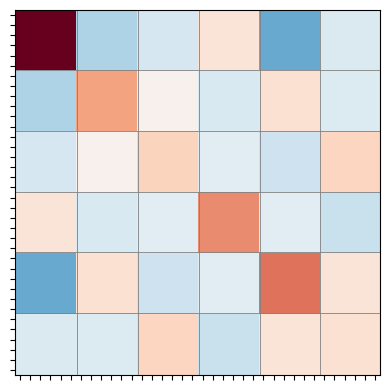

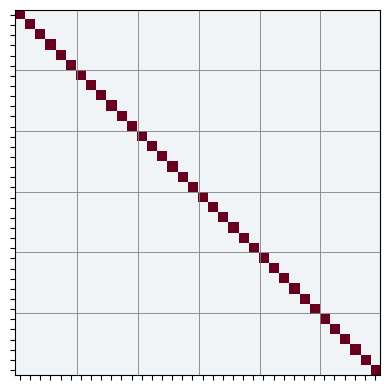

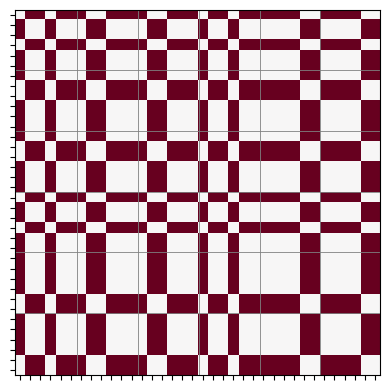

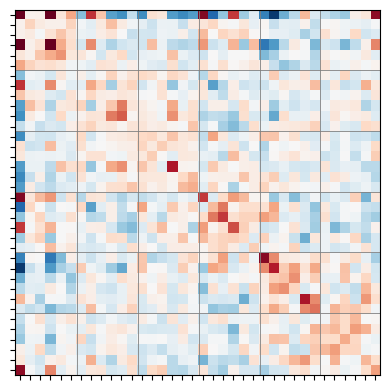

In [ ]:
region = 'SPLp'

labels = ['flx_flx',    'flx_flxup',   'flx_extup',   'flx_ext',   'flx_extdn',   'flx_flxdn',
          'flxup_flx',  'flxup_flxup', 'flxup_extup', 'flxup_ext', 'flxup_extdn', 'flxup_flxdn',
          'extup_flx',  'extup_flxup', 'extup_extup', 'extup_ext', 'extup_extdn', 'extup_flxdn',
          'ext_flx',    'ext_flxup',   'ext_extup',   'ext_ext',   'ext_extdn',   'ext_flxdn',
          'extdn_flx',  'extdn_flxup', 'extdn_extup', 'extdn_ext', 'extdn_extdn', 'extdn_flxdn',
          'flxdn_flx',  'flxdn_flxup', 'flxdn_extup', 'flxdn_ext', 'flxdn_extdn', 'flxdn_flxdn']
cmap = 'RdBu_r'
ncond = 36

# one-hot unrelated conditions:
cov_unrel = np.zeros((ncond,ncond)) #np.eye(ncond)
idx_unrel = [1,2,4,5, 6,9,10,11, 12,15,16,17, 19,20,22,23, 24,25,26,27, 30,31,32,33]
F_unrel = np.zeros((ncond,1))
F_unrel[idx_unrel,0] = 1
cov_unrel = F_unrel @ F_unrel.T
# cov_unrel = pcm.G_to_dist(cov_unrel)

# OLS components:
# Generate the three model components, each one as a fixed model
A = np.zeros((ncond, 6))
for i in range(6):
    A[i*6:(i+1)*6, i] = 1.0
B = np.tile(np.eye(6), (6, 1))
I = np.eye(ncond)
# Orthogonalize the interaction effect
X = np.c_[A, B]
Io = I - X @ np.linalg.pinv(X) @ I
Io = I # not orthogonalized interaction

# Now Build the second moment matrix and create the full model
# for data generation:
Gc = np.zeros((4, ncond, ncond))
Gc[0] = pcm.centering(ncond) @ A @ A.T @ pcm.centering(ncond) # eye contra
Gc[1] = pcm.centering(ncond) @ B @ B.T @ pcm.centering(ncond) # ipsi
Gc[2] = pcm.centering(ncond) @ Io @ Io.T @ pcm.centering(ncond) # interaction
Gc[3] = cov_unrel #pcm.centering(ncond) @ cov_unrel @ pcm.centering(ncond) # incongruency
# Gc[3] = cov_unrel

# get Guni from data:
F_contra = np.zeros((36,6))
cnd2idx = {'flx':0, 'flxup':1, 'extup':2, 'ext':3, 'extdn':4, 'flxdn':5}
for i in range(36):
    cond_pair = labels[i].split('_')
    cnd_contra = cond_pair[0]
    cnd_ipsi = cond_pair[1]
    idx_contra = cnd2idx[cnd_contra]
    idx_ipsi = cnd2idx[cnd_ipsi]
    F_contra[i, idx_contra] = 1
# center the features:
F_contra -= np.mean(F_contra, axis=0)
F = F_contra

# load dataset:
file_path_save = os.path.join(analysisDir, f'pcm_dataset_bimanual_{region}.npz')
D = np.load(file_path_save, allow_pickle=True)
D = D['Y'].tolist()

# load unimanual 6b6:
file_path_unimanual = os.path.join(analysisDir, f'pcm_dataset_6by6_{region}.npz')
U = np.load(file_path_unimanual, allow_pickle=True)
# select only contralateral: 
# contra_idx = U['identifier']=='contra'
U = U['Y']#[contra_idx[0]]
Guni = np.zeros((6, 6))
for i in range(len(U)):
    tmp,_ = pcm.est_G_crossval(U[i].measurements,
                                U[i].obs_descriptors['cond_vec'],
                                U[i].obs_descriptors['part_vec'],
                                X=pcm.matrix.indicator(U[i].obs_descriptors['part_vec']))
    Guni += tmp
Guni /= len(U)
# Guni = np.eye(6) * np.trace(Guni) / 6 # isotropic model with same variance as unimanual contra
Gc_contra = F @ Guni @ F.T # contra model with covariance structure

M = []
M.append(pcm.ComponentModel('contra', [Gc_contra]))
M.append(pcm.ComponentModel('incongruency', [Gc_contra,Gc[3]]))
M.append(pcm.ComponentModel('interaction', [Gc_contra,Gc[2]]))
M.append(pcm.ComponentModel('incongruency+interaction', [Gc_contra,Gc[3],Gc[2]]))

# visualize components:
for i in range(3):
    fig, ax = plt.subplots(figsize=(4,4))
    # get M[i] component matrix:
    G = [Gc_contra, Gc[2], Gc[3]][i]
    vmin = -np.max(np.abs(G))
    vmax = np.max(np.abs(G))
    im = ax.imshow(G, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    for j in range(5):
        ax.axvline((j+1)*6-0.37, color='grey', linewidth=0.6, linestyle='-')
        ax.axhline((j+1)*6-0.6, color='grey', linewidth=0.6, linestyle='-')
    # ax.set_title(['Contra', 'Interaction', 'incongruency'][i])
    ax.set_xticks(np.arange(ncond))
    ax.set_yticks(np.arange(ncond))
    ax.set_xticklabels('')
    ax.set_yticklabels('')
    plt.tight_layout()
    # save fig:
    fig.savefig(os.path.join('/Users/aghavamp/Desktop/Projects/bimanual_wrist/figures', f"{['Contra', 'Interaction', 'incongruency'][i]}_{region}.pdf"))
    plt.show()

# vusalize bimanual G_hat:
G_bi = np.zeros((36, 36))
for i in range(len(D)):
    tmp,_ = pcm.est_G_crossval(D[i].measurements,   
                                D[i].obs_descriptors['cond_vec'],
                                D[i].obs_descriptors['part_vec'],
                                X=pcm.matrix.indicator(D[i].obs_descriptors['part_vec']))
    G_bi += tmp
G_bi /= len(D)

# visualize G_bi:
fig, ax = plt.subplots(figsize=(4,4))
vmax = np.max(np.abs(G_bi))/3
vmin = -vmax
im = ax.imshow(G_bi, cmap='RdBu_r', vmin=vmin, vmax=vmax)
# line evrey 6 rows and columns:
for i in range(5):
    ax.axvline((i+1)*6-0.37, color='grey', linewidth=0.6, linestyle='-')
    ax.axhline((i+1)*6-0.6, color='grey', linewidth=0.6, linestyle='-')
ax.set_xticks(np.arange(ncond))
ax.set_yticks(np.arange(ncond))
ax.set_xticklabels('')
ax.set_yticklabels('')
plt.tight_layout()
plt.savefig(os.path.join('/Users/aghavamp/Desktop/Projects/bimanual_wrist/figures', f"bimanual_G_{region}.pdf"))
plt.show()



### fit CKA

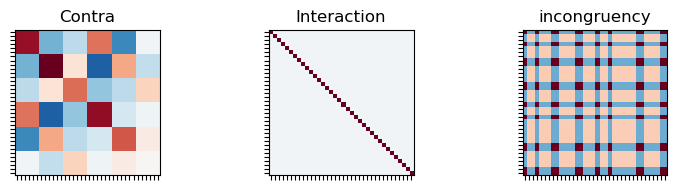

M1 - Fitting CKA crossval...


/Users/aghavamp/Desktop/Projects/PcmPy/PcmPy/model.py:175: RuntimeWarning: overflow encountered in exp
  exp_theta=np.reshape(np.exp(theta),(theta.size,1,1)) # Bring into the right shape for broadcasting
/Users/aghavamp/Desktop/Projects/PcmPy/PcmPy/inference_cka.py:32: RuntimeWarning: invalid value encountered in matmul
  G_centered = H @ G @ H


S1 - Fitting CKA crossval...


/Users/aghavamp/Desktop/Projects/PcmPy/PcmPy/model.py:175: RuntimeWarning: overflow encountered in exp
  exp_theta=np.reshape(np.exp(theta),(theta.size,1,1)) # Bring into the right shape for broadcasting
/Users/aghavamp/Desktop/Projects/PcmPy/PcmPy/inference_cka.py:32: RuntimeWarning: invalid value encountered in matmul
  G_centered = H @ G @ H


PMd - Fitting CKA crossval...


...

PMv - Fitting CKA crossval...


/Users/aghavamp/Desktop/Projects/PcmPy/PcmPy/model.py:175: RuntimeWarning: overflow encountered in exp
  exp_theta=np.reshape(np.exp(theta),(theta.size,1,1)) # Bring into the right shape for broadcasting
/Users/aghavamp/Desktop/Projects/PcmPy/PcmPy/inference_cka.py:32: RuntimeWarning: invalid value encountered in matmul
  G_centered = H @ G @ H


SMA - Fitting CKA crossval...


/Users/aghavamp/Desktop/Projects/PcmPy/PcmPy/model.py:175: RuntimeWarning: overflow encountered in exp
  exp_theta=np.reshape(np.exp(theta),(theta.size,1,1)) # Bring into the right shape for broadcasting
/Users/aghavamp/Desktop/Projects/PcmPy/PcmPy/inference_cka.py:32: RuntimeWarning: invalid value encountered in matmul
  G_centered = H @ G @ H


SPLa - Fitting CKA crossval...
SPLp - Fitting CKA crossval...
V1 - Fitting CKA crossval...
variable       CKA                                                     CKA_fit                                                   iterations                                                   region lower_ceil upper_ceil
model       contra incongruency interaction incongruency+interaction    contra incongruency interaction incongruency+interaction     contra incongruency interaction incongruency+interaction                             
0         0.326048     0.321951    0.329588                 0.326049  0.626647     0.639069    0.644648                 0.652513       40.0          6.0        47.0                     47.0     M1   0.373018   0.385696
1         0.019044     0.022915    0.026501                 0.028633  0.628210     0.640556    0.646103                 0.653820       40.0         52.0        54.0                     12.0     M1   0.068732   0.078110
2         0.073822     0.081197  

In [18]:
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

labels = ['flx_flx',    'flx_flxup',   'flx_extup',   'flx_ext',   'flx_extdn',   'flx_flxdn',
          'flxup_flx',  'flxup_flxup', 'flxup_extup', 'flxup_ext', 'flxup_extdn', 'flxup_flxdn',
          'extup_flx',  'extup_flxup', 'extup_extup', 'extup_ext', 'extup_extdn', 'extup_flxdn',
          'ext_flx',    'ext_flxup',   'ext_extup',   'ext_ext',   'ext_extdn',   'ext_flxdn',
          'extdn_flx',  'extdn_flxup', 'extdn_extup', 'extdn_ext', 'extdn_extdn', 'extdn_flxdn',
          'flxdn_flx',  'flxdn_flxup', 'flxdn_extup', 'flxdn_ext', 'flxdn_extdn', 'flxdn_flxdn']
cmap = 'RdBu_r'
ncond = 36

# one-hot unrelated conditions:
cov_unrel = np.zeros((ncond,ncond)) #np.eye(ncond)
idx_unrel = [1,2,4,5, 6,9,10,11, 12,15,16,17, 19,20,22,23, 24,25,26,27, 30,31,32,33]
for i in range(len(idx_unrel)):
    for j in range(len(idx_unrel)):
        if i != j:
            cov_unrel[idx_unrel[i], idx_unrel[j]] = 1
F_unrel = np.zeros((ncond,1))
F_unrel[idx_unrel,0] = 1
cov_unrel = F_unrel @ F_unrel.T

# OLS components:
# Generate the three model components, each one as a fixed model
A = np.zeros((ncond, 6))
for i in range(6):
    A[i*6:(i+1)*6, i] = 1.0
B = np.tile(np.eye(6), (6, 1))
I = np.eye(ncond)
# Orthogonalize the interaction effect
X = np.c_[A, B]
Io = I - X @ np.linalg.pinv(X) @ I
Io = I # not orthogonalized interaction

# Now Build the second moment matrix and create the full model
# for data generation:
Gc = np.zeros((4, ncond, ncond))
Gc[0] = pcm.centering(ncond) @ A @ A.T @ pcm.centering(ncond) # eye contra
Gc[1] = pcm.centering(ncond) @ B @ B.T @ pcm.centering(ncond) # ipsi
Gc[2] = pcm.centering(ncond) @ Io @ Io.T @ pcm.centering(ncond) # interaction
Gc[3] = pcm.centering(ncond) @ cov_unrel @ pcm.centering(ncond) # incongruency

# get Guni from data:
F_contra = np.zeros((36,6))
cnd2idx = {'flx':0, 'flxup':1, 'extup':2, 'ext':3, 'extdn':4, 'flxdn':5}
for i in range(36):
    cond_pair = labels[i].split('_')
    cnd_contra = cond_pair[0]
    cnd_ipsi = cond_pair[1]
    idx_contra = cnd2idx[cnd_contra]
    idx_ipsi = cnd2idx[cnd_ipsi]
    F_contra[i, idx_contra] = 1
# center the features:
F_contra -= np.mean(F_contra, axis=0)
F = F_contra
# Gc[4] = F @ Guni @ F.T

df = []
theta_cv_region = []
for region in regions:
    # load dataset:
    file_path_save = os.path.join(analysisDir, f'pcm_dataset_bimanual_{region}.npz')
    D = np.load(file_path_save, allow_pickle=True)
    D = D['Y'].tolist()

    # load unimanual 6b6:
    file_path_unimanual = os.path.join(analysisDir, f'pcm_dataset_6by6_{region}.npz')
    U = np.load(file_path_unimanual, allow_pickle=True)
    # select only contralateral: 
    # contra_idx = U['identifier']=='contra'
    U = U['Y']#[contra_idx[0]]
    Guni = np.zeros((6, 6))
    for i in range(len(U)):
        tmp,_ = pcm.est_G_crossval(U[i].measurements,
                                    U[i].obs_descriptors['cond_vec'],
                                    U[i].obs_descriptors['part_vec'],
                                    X=pcm.matrix.indicator(U[i].obs_descriptors['part_vec']))
        Guni += tmp
    Guni /= len(U)
    # Guni = np.eye(6) * np.trace(Guni) / 6 # isotropic model with same variance as unimanual contra
    Gc_contra = F @ Guni @ F.T # contra model with covariance structure
    
    M = []
    M.append(pcm.ComponentModel('contra', [Gc_contra]))
    M.append(pcm.ComponentModel('incongruency', [Gc_contra,Gc[3]]))
    M.append(pcm.ComponentModel('interaction', [Gc_contra,Gc[2]]))
    M.append(pcm.ComponentModel('incongruency+interaction', [Gc_contra,Gc[3],Gc[2]]))

    # visualize components:
    if region == 'M1': # only plot for M1
        fig, ax = plt.subplots(1,3, figsize=(8,2))
        for i in range(3):
            # get M[i] component matrix:
            G = [Gc_contra, Gc[2], Gc[3]][i]
            vmin = -np.max(np.abs(G))
            vmax = np.max(np.abs(G))
            im = ax[i].imshow(G, cmap='RdBu_r', vmin=vmin, vmax=vmax)
            ax[i].set_title(['Contra', 'Interaction', 'incongruency'][i])
            ax[i].set_xticks(np.arange(ncond))
            ax[i].set_yticks(np.arange(ncond))
            ax[i].set_xticklabels('')
            ax[i].set_yticklabels('')
        plt.tight_layout()
        plt.show()
        
    # ================================ fit CKA ================================
    print(f'{region} - Fitting CKA crossval...')
    T_cv, theta_cv, ceil = pcm.fit_CKA_group_crossval(D, M, verbose=False, ceil=True)
    theta_cv_region.append(theta_cv)
    # add region to T_cv:
    T_cv['region'] = region
    # add low_ceil and high_ceil to T_cv:
    T_cv['lower_ceil'] = ceil['ceil_low']
    T_cv['upper_ceil'] = ceil['ceil_high']
    # append to df:
    df.append(T_cv)

# append all regions:
df = pd.concat(df, ignore_index=True)
print(df.to_string())



### PLOT

In [20]:
df_rm = df.copy()
df_rm = df_rm[df_rm['region']=='SPLp']
CKA = df_rm['CKA'].copy().reset_index(drop=True)
CKA
# subject mean across models:
CKA_subj = np.mean(CKA.values, axis=1)

# remove subject mean from each row of CKA but keep it as dataframe:
CKA_rm = CKA.values - CKA_subj[:,None]

# add back the global mean to all rows and columns:
CKA_rm = CKA_rm + np.mean(CKA_subj)
CKA_rm = pd.DataFrame(CKA_rm, columns=CKA.columns)
CKA_rm

model,contra,incongruency,interaction,incongruency+interaction
0,0.139545,0.156690,0.159389,0.166667
1,0.175588,0.165734,0.134551,0.146419
2,0.166795,0.132462,0.179247,0.143788
3,0.150094,0.152363,0.160827,0.159008
4,0.045699,0.254103,0.071834,0.250656
5,0.155275,0.150360,0.160645,0.156012
6,0.158291,0.144217,0.168306,0.151478
7,0.080936,0.210136,0.113425,0.217795
8,0.178108,0.136789,0.167748,0.139646
9,0.056335,0.232076,0.095002,0.238878


M1:


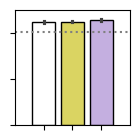

S1:


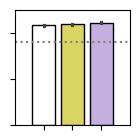

PMd:


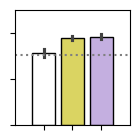

PMv:


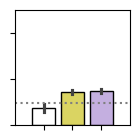

SMA:


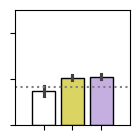

SPLa:


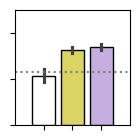

SPLp:


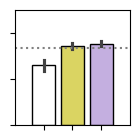

V1:


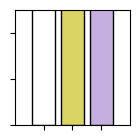

In [69]:
for r in regions:
    df_region = df[df['region'] == r]
    print(f'{r}:')
    df_CKA = df_region['CKA'].copy().reset_index(drop=True)
    # remove contra model:
    df_CKA = df_CKA.drop(columns=['interaction'])

    CKA_subj = np.mean(df_CKA.values, axis=1)
    CKA_rm = df_CKA.values - CKA_subj[:,None]
    # add back the global mean to all rows and columns:
    CKA_rm = CKA_rm + np.mean(CKA_subj)
    CKA_rm = pd.DataFrame(CKA_rm, columns=df_CKA.columns)
    df_CKA = CKA_rm.copy()

    lower_ceil = np.mean(df_region['lower_ceil'].values)
    # upper_ceil = np.mean(df_region['upper_ceil'].values)
    fig, ax = plt.subplots(figsize=(1.5,1.5))
    sns.barplot(data=df_CKA, ax=ax, width=0.8, errorbar='se',edgecolor="black",
                palette=['#ffffff','#EEE64E','#C3A7E8'], alpha=1)
    # sns.pointplot(data=df_CKA, ax=ax, linestyles=':', errorbar='se')
    # ax.set_ylim(0.2,0.3)
    ax.set_xlim(-1,3)
    ax.axhline(lower_ceil, color='gray', linestyle=':', label='Lower Ceiling')

    ax.set_ylim(0,0.25)
    ax.set_yticklabels([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    plt.tight_layout()
    plt.savefig(os.path.join('/Users/aghavamp/Desktop/Projects/bimanual_wrist/figures/model_comparison', f"{r}_CKA.pdf"))
    plt.show()




### STATs

In [10]:
# is +incongruency > only contra?
# is +interaction > only contra?
# is incongruency > interaction?
# is interaction > incongruency?
# is interaction+incongruency > interaction alone?
# is interaction+incongruency > incongruency alone?
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']

df_stats = {'region': [], 'comparison': [], 'mean_diff': [], 'dof': [], 't_stat': [], 'p_val': []}
for r in regions:
    df_region = df[df['region'] == r]
    df_CKA = df_region['CKA'].copy().reset_index(drop=True)
    incongruency = df_CKA['incongruency'].values
    interaction = df_CKA['interaction'].values
    incongruency_interaction = df_CKA['incongruency+interaction'].values
    only_contra = df_CKA['contra'].values
    ceil = df_region['lower_ceil'].values

    # +incongruency > only contra
    t_stat, p_val = stats.ttest_rel(incongruency, only_contra, alternative='greater')
    df_stats['region'].append(r)
    df_stats['comparison'].append('incongruency > contra')
    df_stats['mean_diff'].append(np.mean(incongruency) - np.mean(only_contra))
    df_stats['dof'].append(len(incongruency)-1)
    df_stats['t_stat'].append(t_stat)
    df_stats['p_val'].append(p_val)

    # +interaction > only contra
    t_stat, p_val = stats.ttest_rel(interaction, only_contra, alternative='greater')
    df_stats['region'].append(r)
    df_stats['comparison'].append('interaction > contra')
    df_stats['mean_diff'].append(np.mean(interaction) - np.mean(only_contra))
    df_stats['dof'].append(len(interaction)-1)
    df_stats['t_stat'].append(t_stat)
    df_stats['p_val'].append(p_val)

    # incongruency > interaction
    t_stat, p_val = stats.ttest_rel(incongruency, interaction, alternative='greater')
    df_stats['region'].append(r)
    df_stats['comparison'].append('incongruency > interaction')
    df_stats['mean_diff'].append(np.mean(incongruency) - np.mean(interaction))
    df_stats['dof'].append(len(incongruency)-1)
    df_stats['t_stat'].append(t_stat)
    df_stats['p_val'].append(p_val)

    # interaction > incongruency
    t_stat, p_val = stats.ttest_rel(interaction, incongruency, alternative='greater')
    df_stats['region'].append(r)
    df_stats['comparison'].append('interaction > incongruency')
    df_stats['mean_diff'].append(np.mean(interaction) - np.mean(incongruency))
    df_stats['dof'].append(len(interaction)-1)
    df_stats['t_stat'].append(t_stat)
    df_stats['p_val'].append(p_val)

    # interaction < ceil:
    # t_stat, p_val = stats.ttest_rel(interaction, ceil, alternative='less')
    # df_stats['region'].append(r)
    # df_stats['comparison'].append('interaction < ceil')
    # df_stats['mean_diff'].append(np.mean(interaction) - lower_ceil)
    # df_stats['dof'].append(len(interaction)-1)
    # df_stats['t_stat'].append(t_stat)
    # df_stats['p_val'].append(p_val)

    # # incongruency < ceil:
    # t_stat, p_val = stats.ttest_rel(incongruency, ceil, alternative='less')
    # df_stats['region'].append(r)
    # df_stats['comparison'].append('incongruency < ceil')
    # df_stats['mean_diff'].append(np.mean(incongruency) - lower_ceil)
    # df_stats['dof'].append(len(incongruency)-1)
    # df_stats['t_stat'].append(t_stat)
    # df_stats['p_val'].append(p_val)

    # interaction+incongruency > interaction alone
    t_stat, p_val = stats.ttest_rel(incongruency_interaction, interaction, alternative='greater')
    df_stats['region'].append(r)
    df_stats['comparison'].append('incongruency+interaction > interaction')
    df_stats['mean_diff'].append(np.mean(incongruency_interaction) - np.mean(interaction))
    df_stats['dof'].append(len(incongruency_interaction)-1)
    df_stats['t_stat'].append(t_stat)
    df_stats['p_val'].append(p_val)

    # interaction+incongruency > incongruency alone
    t_stat, p_val = stats.ttest_rel(incongruency_interaction, incongruency, alternative='greater')
    df_stats['region'].append(r)
    df_stats['comparison'].append('incongruency+interaction > incongruency')
    df_stats['mean_diff'].append(np.mean(incongruency_interaction) - np.mean(incongruency))
    df_stats['dof'].append(len(incongruency_interaction)-1)
    df_stats['t_stat'].append(t_stat)
    df_stats['p_val'].append(p_val)

df_stats = pd.DataFrame(df_stats)

# FDR correction across regions for each comparison separately:
for comparison in df_stats['comparison'].unique():
    df_comparison = df_stats[df_stats['comparison'] == comparison]
    reject, p_corr, _, _ = multipletests(df_comparison['p_val'], alpha=0.05, method='fdr_bh')
    df_stats.loc[df_stats['comparison'] == comparison, 'p_fdr'] = p_corr
    df_stats.loc[df_stats['comparison'] == comparison, 'reject_H0'] = reject

print(df_stats.to_string())



   region                               comparison     mean_diff  dof    t_stat     p_val     p_fdr reject_H0
0      M1                    incongruency > contra  8.991175e-04   23  0.479243  0.318146  0.348602     False
1      M1                     interaction > contra  4.430990e-03   23  2.006148  0.028370  0.037827      True
2      M1               incongruency > interaction -3.531873e-03   23 -2.064743  0.974800  0.999879     False
3      M1               interaction > incongruency  3.531873e-03   23  2.064743  0.025200  0.100800     False
4      M1   incongruency+interaction > interaction  1.468302e-04   23  0.113142  0.455450  0.455450     False
5      M1  incongruency+interaction > incongruency  3.678703e-03   23  2.206823  0.018790  0.025265      True
6      S1                    incongruency > contra  1.986058e-03   23  1.368364  0.092209  0.122945     False
7      S1                     interaction > contra  3.792779e-03   23  2.167905  0.020380  0.032609      True
8      S1 

## Simulation

### Is averaging equivalent to OLS?

#### generate data

In [ ]:
np.random.seed(0)
ncond = 36

nsim = 200
s = [0.02]*nsim
cond_vec, part_vec = pcm.sim.make_design(n_cond=ncond, n_part=10)
theta_true = np.array([0,-4,-1])


# Generate the three model components, each one as a fixed model
A = np.zeros((ncond, 6))
for i in range(6):
    A[i*6:(i+1)*6, i] = 1.0
B = np.tile(np.eye(6), (6, 1))
I = np.eye(ncond)
# Orthogonalize the interaction effect
X = np.c_[A, B]
Io = I - X @ np.linalg.pinv(X) @ I

# Now Build the second moment matrix and create the full model
# for data generation:
Gc = np.zeros((3, ncond, ncond))
Gc[0] = pcm.centering(ncond) @ A @ A.T @ pcm.centering(ncond)
Gc[1] = pcm.centering(ncond) @ B @ B.T @ pcm.centering(ncond)
Gc[2] = pcm.centering(ncond) @ Io @ Io.T @ pcm.centering(ncond)

MC = pcm.ComponentModel('ABC', [Gc[0], Gc[1], Gc[2]])

# results_path = os.path.join('./results/MF_PCM/')

# if not os.path.exists(results_path):
#     os.makedirs(results_path)

# Show the three model components
for i in range(3):
    ax = plt.subplot(1, 3, i + 1)
    vmin = -np.max(np.abs(Gc[i]))
    vmax = np.max(np.abs(Gc[i]))
    plt.imshow(Gc[i], cmap='RdBu_r', vmin=vmin, vmax=vmax)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.colorbar()

D2 = pcm.G_to_dist(Gc[2])
# mean of diagonal - mean of off-diagonal:
avg = np.mean(np.diag(Gc[2])) - np.mean(Gc[2][np.where(~np.eye(Gc[2].shape[0],dtype=bool))])
print(avg*2.0)
print(np.sum(D2) / (ncond**2 - ncond))

D = pcm.sim.make_dataset(model=MC,
    theta=theta_true,
    cond_vec=cond_vec,
    part_vec=part_vec,
    n_sim=nsim,
    n_channel=300,
    signal=s)

# estimate G_hat:
G_hat = np.zeros((nsim, ncond, ncond))
for i in range(nsim):
    G_hat[i, :, :], _ = pcm.est_G_crossval(D[i].measurements,
                                            D[i].obs_descriptors['cond_vec'],
                                            D[i].obs_descriptors['part_vec'],
                                            X=pcm.matrix.indicator(D[i].obs_descriptors['part_vec']))
Gmean = np.mean(G_hat, axis=0)
# visualize the estimated G:
plt.figure(figsize=(3,3))
vmin = -np.max(np.abs(Gmean))
vmax = np.max(np.abs(Gmean))
plt.imshow(Gmean, cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title('Estimated G mean over simulations')
plt.xlabel('Conditions')
plt.ylabel('Conditions')
plt.xticks(ticks=np.arange(ncond), labels=np.arange(1,ncond+1), rotation=45)
plt.yticks(ticks=np.arange(ncond), labels=np.arange(1,ncond+1))
plt.tight_layout()
plt.show()

# # PCM Model Fit:
# M = [MC]
# # T, theta = pcm.fit_model_individ(D, M, fixed_effect='block', verbose=False)
# T, theta = fit_CKA_individ(D, M, fixed_effect='block', verbose=False)
# T_pcm, theta_pcm = pcm.fit_model_individ(D, M, fit_scale=False, fixed_effect='block', verbose=False)

# # OLS Model Fit:
# X = np.vstack([Gc[0].flatten(), Gc[1].flatten(), Gc[2].flatten()]).T
# W = []
# for i in range(nsim):
#     tmp_w = np.linalg.pinv((X.T@X)) @ X.T @ G_hat[i].flatten()
#     W.append(tmp_w)
# W = np.array(W)



#### calculate contra marginal Y

In [ ]:
partitions = np.unique(D[0].obs_descriptors['part_vec'])
Y_marginal = np.zeros((nsim, 6*len(partitions), D[0].measurements.shape[1]))
part_vec = np.repeat(np.arange(len(partitions)), 6)
cond_vec = np.tile(np.arange(6), len(partitions))
for i in range(nsim):
    for p in partitions:
        for c in range(6):
            # select the part of full data D:
            idx = np.where((D[i].obs_descriptors['part_vec'] == p) & 
                           (D[i].obs_descriptors['cond_vec']>=(c)*6) & 
                           (D[i].obs_descriptors['cond_vec']<(c+1)*6))[0]
            Y_marginal[i, int(c + p*6), :] = np.mean(D[i].measurements[idx, :], axis=0)

G_hat_contra = np.zeros((nsim, 6, 6))
for i in range(nsim):
    G_hat_contra[i, :, :], _ = pcm.est_G_crossval(Y_marginal[i],
                                            cond_vec,
                                            part_vec,
                                            X=pcm.matrix.indicator(part_vec))

G_mean_contra = np.mean(G_hat_contra, axis=0)
plt.figure(figsize=(3,3))
vmin = -np.max(np.abs(G_mean_contra))
vmax = np.max(np.abs(G_mean_contra))
plt.imshow(G_mean_contra, cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title('Estimated G marginal mean over simulations')
plt.xlabel('Conditions')
plt.ylabel('Conditions')
plt.xticks(ticks=np.arange(6), labels=np.arange(1,7), rotation=45)
plt.yticks(ticks=np.arange(6), labels=np.arange(1,7))
plt.tight_layout()
plt.show()



#### calculate ipsi marginal Y

In [ ]:
partitions = np.unique(D[0].obs_descriptors['part_vec'])
Y_marginal = np.zeros((nsim, 6*len(partitions), D[0].measurements.shape[1]))
part_vec = np.repeat(np.arange(len(partitions)), 6)
cond_vec = np.tile(np.arange(6), len(partitions))
for i in range(nsim):
    for p in partitions:
        for c in range(6):
            # select the part of full data D:
            idx = np.where((D[i].obs_descriptors['part_vec'] == p) & 
                           (D[i].obs_descriptors['cond_vec']%6 == c))[0]
            Y_marginal[i, int(c + p*6), :] = np.mean(D[i].measurements[idx, :], axis=0)

G_hat_ipsi = np.zeros((nsim, 6, 6))
for i in range(nsim):
    G_hat_ipsi[i, :, :], _ = pcm.est_G_crossval(Y_marginal[i],
                                            cond_vec,
                                            part_vec,
                                            X=pcm.matrix.indicator(part_vec))

G_mean_ipsi = np.mean(G_hat_ipsi, axis=0)
plt.figure(figsize=(3,3))
vmin = -np.max(np.abs(G_mean_ipsi))
vmax = np.max(np.abs(G_mean_ipsi))
plt.imshow(G_mean_ipsi, cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title('Estimated G marginal mean over simulations')
plt.xlabel('Conditions')
plt.ylabel('Conditions')
plt.xticks(ticks=np.arange(6), labels=np.arange(1,7), rotation=45)
plt.yticks(ticks=np.arange(6), labels=np.arange(1,7))
plt.tight_layout()
plt.show()



#### compare OLS with estimated_G_marginal

In [ ]:
# OLS Model Fit:
X = np.vstack([Gc[0].flatten(), Gc[1].flatten(), Gc[2].flatten()]).T
W = []
pinvX = np.linalg.pinv(X)
for i in range(nsim):
    tmp_w = pinvX @ G_hat[i,:,:].flatten()
    W.append(tmp_w)
W = np.array(W)

# estimate variance from OLS:
var_contra_ols = W[:,0] * np.trace(Gc[0])/ncond
var_ipsi_ols = W[:,1] * np.trace(Gc[1])/ncond
var_interaction_ols = W[:,2] * np.trace(Gc[2])/ncond

# estimate variance from marginal G_hat:
var_contra_marginal = np.trace(G_mean_contra)/G_mean_contra.shape[0]
var_ipsi_marginal = np.trace(G_mean_ipsi)/G_mean_ipsi.shape[0]

print(f'contra\n    ols: {np.mean(var_contra_ols):.6f} vs marginal: {var_contra_marginal:.6f}')
print(f'ipsi\n    ols: {np.mean(var_ipsi_ols):.6f} vs marginal: {var_ipsi_marginal:.6f}')



### OLS

#### make components

In [ ]:
np.random.seed(0)
ncond = 36

# Generate the three model components, each one as a fixed model
A = np.zeros((ncond, 6))
for i in range(6):
    A[i*6:(i+1)*6, i] = 1.0
B = np.tile(np.eye(6), (6, 1))
I = np.eye(ncond)
# Orthogonalize the interaction effect
X = np.c_[A, B]
Io = I - X @ np.linalg.pinv(X) @ I

# Now Build the second moment matrix and create the full model
# for data generation:
Gc = np.zeros((3, ncond, ncond))
Gc[0] = pcm.centering(ncond) @ A @ A.T @ pcm.centering(ncond)
Gc[1] = pcm.centering(ncond) @ B @ B.T @ pcm.centering(ncond)
Gc[2] = pcm.centering(ncond) @ Io @ Io.T @ pcm.centering(ncond)

MC = pcm.ComponentModel('ABC', [Gc[0], Gc[1], Gc[2]])

# results_path = os.path.join('./results/MF_PCM/')

# if not os.path.exists(results_path):
#     os.makedirs(results_path)

# Show the three model components
for i in range(3):
    ax = plt.subplot(1, 3, i + 1)
    vmin = -np.max(np.abs(Gc[i]))
    vmax = np.max(np.abs(Gc[i]))
    plt.imshow(Gc[i], cmap='RdBu_r', vmin=vmin, vmax=vmax)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

D2 = pcm.G_to_dist(Gc[2])
# mean of diagonal - mean of off-diagonal:
avg = np.mean(np.diag(Gc[2])) - np.mean(Gc[2][np.where(~np.eye(Gc[2].shape[0],dtype=bool))])
print(avg*2.0)
print(np.sum(D2) / (ncond**2 - ncond))


#### component correlation

In [ ]:
upper_Gs = [] 
for i in np.arange(3):
    upper_Gs.append(Gc[i][np.triu_indices(Gc[i].shape[0], k=1)]) 
upper_Gs = np.array(upper_Gs)
plt.figure(figsize=(2, 2))
plt.imshow(np.corrcoef(upper_Gs), cmap='bwr', vmin=-1, vmax=1)
plt.xticks([])
plt.yticks([])
plt.title('corr. component Gs')
plt.show()


#### generate data and fit components

In [ ]:
nsim = 200
s = [0.02]*nsim
cond_vec, part_vec = pcm.sim.make_design(n_cond=ncond, n_part=10)
theta_true = np.array([0,-2,0])

D = pcm.sim.make_dataset(model=MC,
    theta=theta_true,
    cond_vec=cond_vec,
    part_vec=part_vec,
    n_sim=nsim,
    n_channel=300,
    signal=s)

# estimate G_hat:
G_hat = np.zeros((nsim, ncond, ncond))
for i in range(nsim):
    G_hat[i, :, :], _ = pcm.est_G_crossval(D[i].measurements,
                                            D[i].obs_descriptors['cond_vec'],
                                            D[i].obs_descriptors['part_vec'],
                                            X=pcm.matrix.indicator(D[i].obs_descriptors['part_vec']))

# PCM Model Fit:
M = [MC]
# T, theta = pcm.fit_model_individ(D, M, fixed_effect='block', verbose=False)
T, theta = fit_CKA_individ(D, M, fixed_effect='block', verbose=False)
T_pcm, theta_pcm = pcm.fit_model_individ(D, M, fit_scale=False, fixed_effect='block', verbose=False)

# OLS Model Fit:
X = np.vstack([Gc[0].flatten(), Gc[1].flatten(), Gc[2].flatten()]).T
W = []
pinvX = np.linalg.pinv(X) 
for i in range(nsim):
    tmp_w = pinvX @ G_hat[i].flatten()
    W.append(tmp_w)
W = np.array(W)



#### plot

In [ ]:
var_contra = np.exp(theta[0][0])
var_ipsi = np.exp(theta[0][1])
var_interaction = np.exp(theta[0][2])

var_contra2 = np.exp(theta_pcm[0][0])
var_ipsi2 = np.exp(theta_pcm[0][1])
var_interaction2 = np.exp(theta_pcm[0][2])

# sns boxplot of theta vs W
fig, ax = plt.subplots(figsize=(4,3))
data = pd.DataFrame({
    'CKA_contra': var_contra,
    'CKA_ipsi': var_ipsi,
    'CKA_interaction': var_interaction,
    'PCM_contra': var_contra2,
    'PCM_ipsi': var_ipsi2,
    'PCM_interaction': var_interaction2,
    'OLS_contra': W[:,0],
    'OLS_ipsi': W[:,1],
    'OLS_interaction': W[:,2],
})
sns.boxplot(data=data, ax=ax)
plt.xticks(rotation=45)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
# plt.title('PCM vs OLS parameter estimates')
plt.tight_layout()
plt.show()


